# Deep Learning Assignment 1
## Logan Justin Gunawan (s4096363)

## Part A: Building the Classifier

### The Task:

This task is a multiclass classification problem using a series of 5 images to classify a string of human gestures as one of 13 gestures. These gesture classifications will then be used for RedKite's line of drones delivering time-critical medical supplies to hard to reach areas. Our main constraint is the performance constraint of the drone's hardware, which is only capable for one modest 2-D CNN classifier. Another important constraint is the limited size of our dataset, containing only ~1000 Instances, or ~5000 Images.

In [1]:
# Imports
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset
import torch.optim as optim
import matplotlib.pyplot as plt
import os
from pathlib import Path
import random
from IPython.display import clear_output

### Exploring the Data:

The dataset is given to us under the folder schema of COMMAND/SUBJECT_ID/INSTANCE_ID/, (e.g AllClear/S1/Instance1) the order of the images in the sequence is given via the naming scheme of the file, e.g ...instance1_1.png, ...instance1_2.png.

The following code creates a DataFrame object where every Image is converted into the Path to that image. When we want to load an image, we will read the image at that specified path.

In [2]:
DATA_PATH = Path.cwd() / "data_resized"
COMMANDS = ["AllClear", "HaveCommand", "Hover",
            "Land", "LandingDirection", "MoveAhead",
            "MoveDownward", "MoveToLeft", "MoveToRight",
            "MoveUpward", "NotClear", "SlowDown",
            "WaveOff"]

# Load the Data
Data = pd.DataFrame(columns=["ID", "Image1", "Image2", "Image3", "Image4", "Image5", "Label"])

def LoadData():
    global Data

    Rows = []

    for Command in COMMANDS:
        FolderPath = DATA_PATH / Command                        # FolderPath <- 'data_resized/AllClear'
        for Folder in os.listdir(FolderPath):
            if Folder == ".DS_Store":
                continue

            FilePath = FolderPath / Folder                # FilePath <- 'data_resized/AllClear/S1'
            for Instance in os.listdir(FilePath):
                if Instance == ".DS_Store":
                    continue

                InstancePath = FilePath / Instance        # InstancePath <- 'data_resized/AllClear/S1/Instance1'
                ImageArray = []
                
                
                for Image in os.listdir(InstancePath):
                    if Image == ".DS_Store":
                        continue

                    ImagePath = InstancePath / Image      # ImagePath <- 'data_resized/AllClear/S1/Instance1/Image1.jpg'

                    ImageArray.append(ImagePath)
                    
                Rows.append(["_".join([Command, Folder, Instance]), 
                                        ImageArray[0], 
                                        ImageArray[1], 
                                        ImageArray[2], 
                                        ImageArray[3], 
                                        ImageArray[4], 
                                        Command])

    Data = pd.DataFrame(Rows, columns = ["ID", "Image1", "Image2", "Image3", "Image4", "Image5", "Label"])

LoadData()

I'd also like to see the class breakdown for Label. Creating a Pie Chart below, I can see some imbalance such as Land taking up ~11% of the Dataset whereas LandingDirection only takes up ~4.5%. However, this is not as concerning as it can be. I will just need to remember to stratify the data later when splitting it to ensure that the model has an equal distribution for training and validating.

([<matplotlib.patches.Wedge at 0x1b0ff3a5550>,
 [Text(1.0635668284994628, 0.2807589737044832, 'AllClear'),
  Text(0.7909714686273195, 0.7644371366028351, 'HaveCommand'),
  Text(0.33246172994177514, 1.048555767770185, 'Hover'),
  Text(-0.32311683962794835, 1.0514730181744307, 'Land'),
  Text(-0.7909714686273194, 0.7644371366028352, 'LandingDirection'),
  Text(-1.0398400246350503, 0.35879342687259197, 'MoveAhead'),
  Text(-1.094733145912591, -0.10751436759950586, 'MoveDownward'),
  Text(-0.9566807502966496, -0.5429198301884356, 'MoveToLeft'),
  Text(-0.518626373978058, -0.9700652989435153, 'MoveToRight'),
  Text(-0.027734483677736066, -1.0996503073318942, 'MoveUpward'),
  Text(0.44233674418895524, -1.0071435869528809, 'NotClear'),
  Text(0.8914506383420925, -0.6444499665602258, 'SlowDown'),
  Text(1.0831939528719474, -0.19154858512044765, 'WaveOff')],
 [Text(0.5801273609997069, 0.15314125838426354, '8.2%'),
  Text(0.4314389828876288, 0.41696571087427364, '8.0%'),
  Text(0.181342761786422

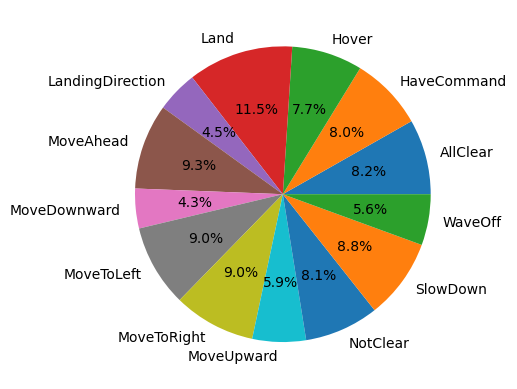

In [3]:
ValCounts = Data["Label"].value_counts()

plt.pie([ValCounts[Col].item() for Col in COMMANDS],
        autopct = '%1.1f%%', 
        labels = COMMANDS)

Next, I create a simple helper function to showcase a collection of the Images in each instance below. This will allow me to easily view the collection of Images associated with any action.

In [4]:
# ---------------------------------------------------------------------------------------
# -----------Code Generated by GitHub Copilot, See End of Notebook for prompt------------
# ---------------------------------------------------------------------------------------

def display_command_instance_images(commands=None, folder="S1", instance="Instance1"):
    if commands is None:
        commands = COMMANDS
    elif isinstance(commands, str):
        commands = [commands]

    invalid_commands = [cmd for cmd in commands if cmd not in COMMANDS]
    if invalid_commands:
        raise ValueError(f"Unsupported command(s): {invalid_commands}")

    rows = len(commands)
    cols = 5

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 4 * rows))

    if rows == 1:
        axes = np.array([axes]).reshape(1, -1)
    elif cols == 1:
        axes = np.array(axes).reshape(-1, 1)
    else:
        axes = np.array(axes)

    for row, command in enumerate(commands):
        instance_dir = DATA_PATH / command / folder / instance
        if not instance_dir.exists():
            raise FileNotFoundError(f"Could not find: {instance_dir}")

        image_files = sorted([
            p for p in instance_dir.iterdir()
            if p.is_file() and p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp", ".gif"}
        ])

        if not image_files:
            raise FileNotFoundError(f"No images found in: {instance_dir}")

        for col in range(cols):
            ax = axes[row, col]
            image_file = image_files[col] if col < len(image_files) else None

            if image_file is None:
                ax.axis("off")
                ax.set_title(f"{command}\nImage {col + 1}\nmissing")
                continue

            ax.imshow(plt.imread(image_file))
            ax.axis("off")
            ax.set_title(f"{command}\nImage {col + 1}")

    plt.tight_layout()
    plt.show()

What I learnt from doing this exploration is the patterns associated with each Command. What this means is that for a drone operator to want to signal a specific Command, they will move to act a certain string of actions in order for the drone to recognize it as a single command. The easiest example of this can be shown below: for the command Hover, the operator will stand in a T formation and remain in position. 

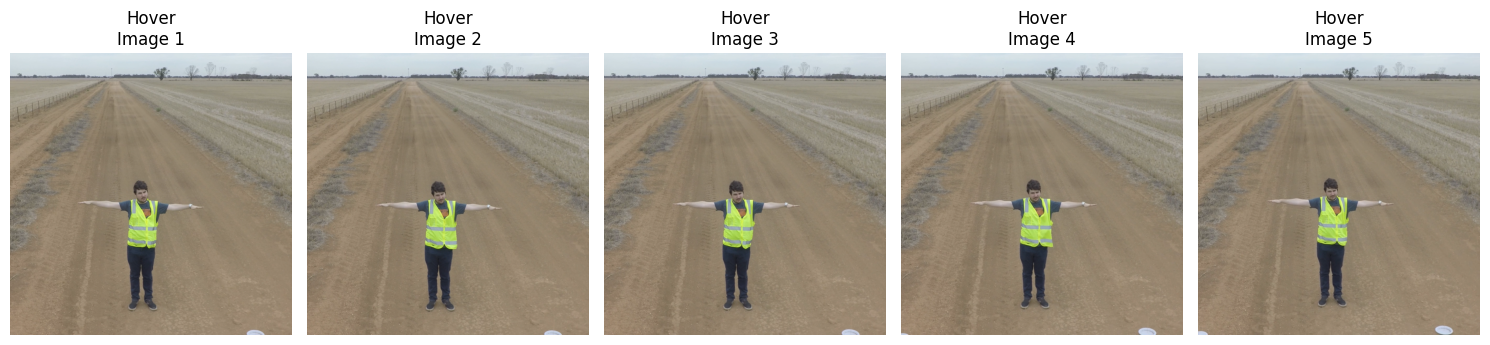

In [5]:
display_command_instance_images(commands=["Hover"], folder="S1", instance="Instance1")

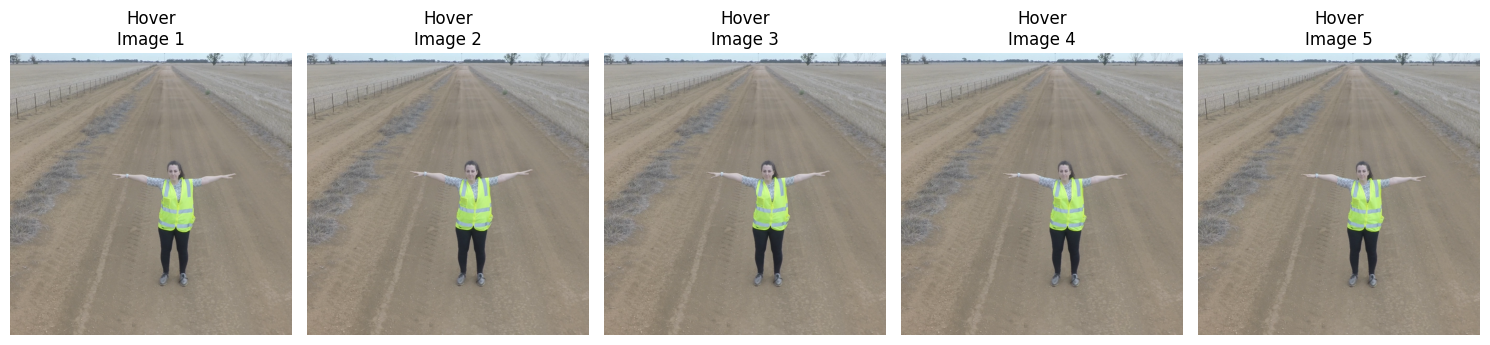

In [6]:
display_command_instance_images(commands=["Hover"], folder="S4", instance="Instance1")

Another example can be Landing Direction where the operator will stand facing their left and put their arms towards their head, then point to the left and repeat that motion.

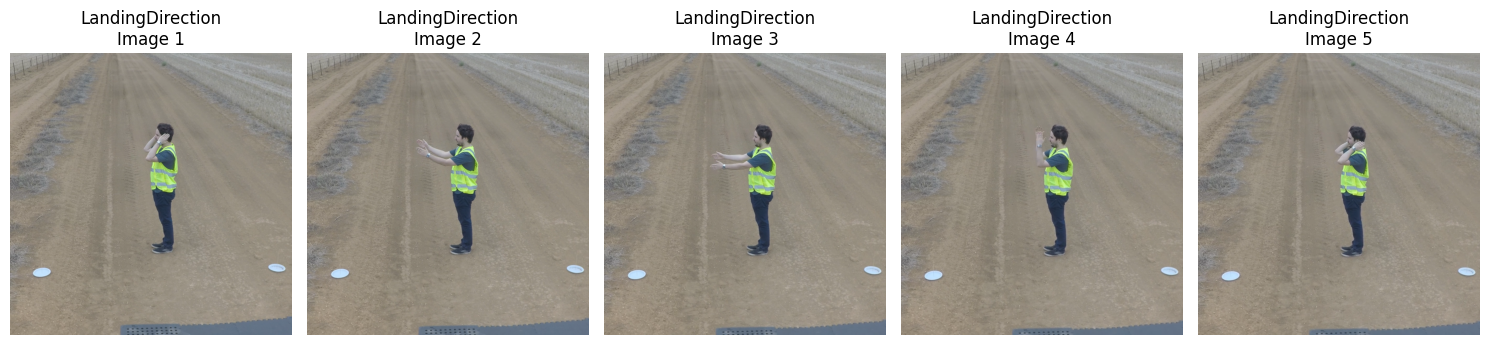

In [7]:
display_command_instance_images(commands=["LandingDirection"], folder="S1", instance="Instance1")

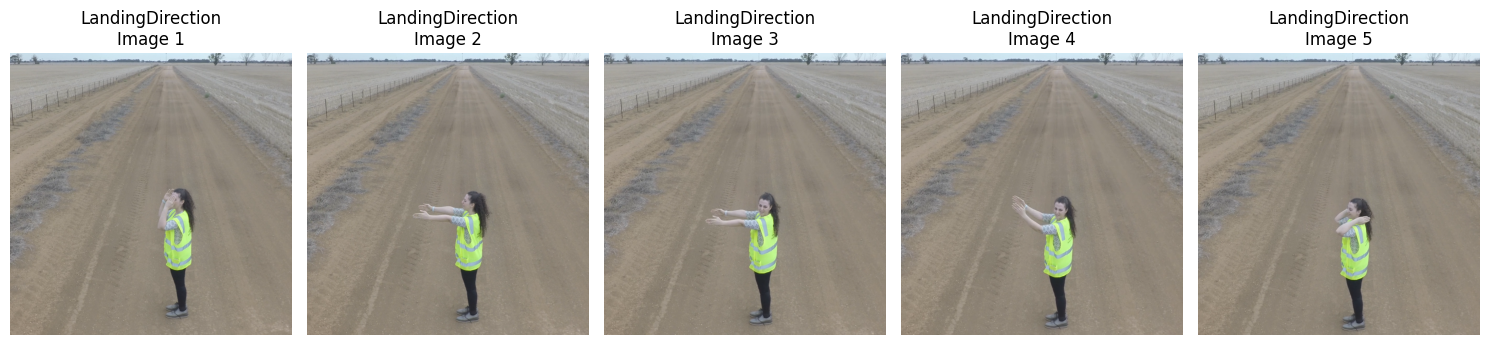

In [8]:
display_command_instance_images(commands=["LandingDirection"], folder="S4", instance="Instance1")

Another thing I noticed was the lack of similar features in many of the images. Whether it be different subjects, different physical environments, different camera angles and positioning, the only constants would be that the human subject will wear a bright hi-vis jacket and use their arms to create gestures. 

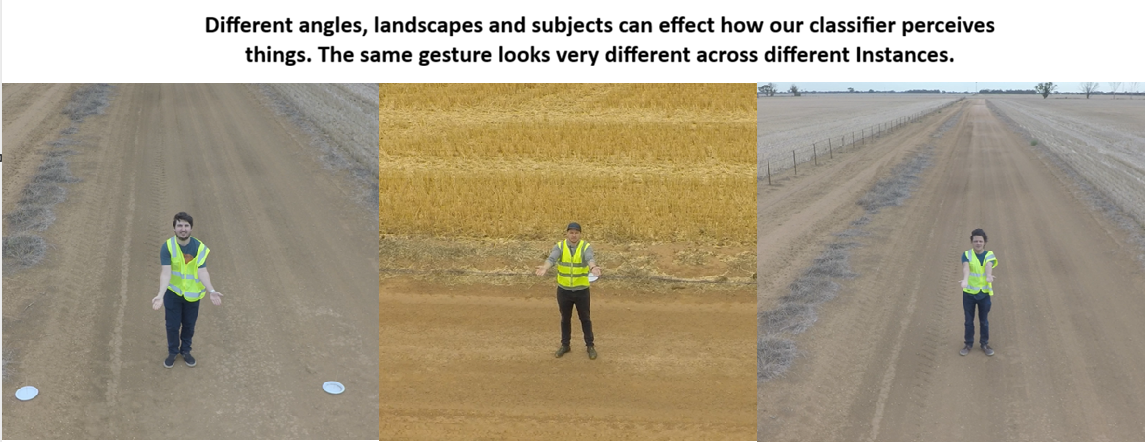

## Building the Models

### The Idea: 

My proposal for the final model revolves around the idea of Feature Extraction on each frame of a row, extracting only the most important features from each Image before passing it through several Dense layers in order to classify a string of Images as being one command. The important feature that I am referring to in each Image will be the "Gesture" represented in each image, because the resulting Action is based on a string of Gestures it may be wise to create a Gesture Recognition Model (GRM) which is will be a CNN classifier as stepping stone to the final Action Model (A.M).

The only hurdle to this task is that creating the GRM will require labelled data for each Gesture, which is not present in the current dataset. To get over this, I decided to label the data myself. 

### Intro to Gestures:

Based on my own observation of the data, I have created myself a set of possible Gestures for each Image to classify as which can be seen in this image below. 

What Gestures I added to the gesture set were based on several of the following considerations.

#### Is this Gesture distinct enough to classify as a its own Gesture?

From a human eye, can I see that there is a very specific Gesture that the subject is trying to portray? From my eyes, I can very distinctly tell that this subject is trying to communicate a T-Pose, becauses if I compare it with any other Gesture, I can very easily tell that these sets of Images are trying to communicate the same distinct pose. 

#### How significant will this Gesture effect the A.M?

What is the significance of this Gesture? One example of this came from an earlier Gesture Set which did not have the Gestures: ThumbsUp and ThumbsDown. These two images below would both be classified as just being LeftNeutral. However, it is important for the model to understand the difference between ThumbsDown and ThumbsUp in these images, because of the commands: AllClear and NotClear which share almost exactly the same Gestures with the exception of ThumbsUp in AllClear and ThumbsDown in NotClear. Not having these models will horribly effect the A.M.

#### How large will the final Gesture Set be?

The Gesture Set should not be too large, we want a set of only the most Significant Gestures to look out for. Insignificant gestures like NeutralHandsOnHip will bloat the Gesture Set and make it more difficult for the GRM to make correct predictions, leading to worse A.M performances.

## Methodology

First I decide on a 60-40 data split, where 60% of the data will go to training and validating the GRM, while 40% of the data will go to training and validating the A.M. What is important here is that I stratify the data based on Action so that I will have an equal distribution of Action strings when training both models.

60% of the data allocated to the GRM will be labelled while the other 40% will not. This roughly equates to ~3100 individual images that will require labelling.

In [9]:
GestureData, RestData = train_test_split(Data,
                                         test_size=0.4,
                                         train_size=0.6,
                                         random_state=67,
                                         stratify=Data["Label"])

GestureData.reset_index(inplace=True)
RestData.reset_index(inplace=True)

In [10]:
SingleImages = pd.DataFrame({
    "Image" : GestureData[["Image1", "Image2", "Image3", "Image4", "Image5"]].to_numpy().flatten()
})

In [11]:
GestureMap = {
    "n" : "Neutral",
    "f" : "Front",
    "p" : "Point",
    "lu" : "LeftUp",
    "ln" : "LeftNeutral",
    "c" : "Cross",
    "uc" : "UpCross",
    "t" : "TPose",
    "tlu" : "TLeftUp",
    "tlo" : "TLeftOut",
    "tlm" : "TLeftMe",
    "tro" : "TRightOut",
    "tru" : "TRightUp",
    "trm" : "TRightMe",
    "flm" : "FrontLeftMe",
    "flu" : "FrontLeftUp",
    "fln" : "FrontLeftNeutral",
    "fm" : "FrontMe",
    "hu" : "HandsUp",
    "luu" : "LeftUpUp",
    "tu" : "ThumbsUp",
    "td" : "ThumbsDown"
}

### Labelling

Below I have created a simple cell code which will display to the user an Image and prompt them to assign it to one of the 13 possible labels. The code will continue until all 3100 Images are labelled. I also save the already labelled images as a Dictionary where the key corresponds to the Index of the image in the dataset and its Value is its assigned label. The code will serialize this Map as a pickle file which acts as a save so that I can do this labelling process across multiple sessions. In total it took ~5 hours.


Right now the code is commented out so that it does not run and obstruct the flow of code in this notebook. To try out the code, rename the existing file LabelMap.pkl to something else, uncomment it then run it. Type 'exit' to stop labelling. (Warning: If you do attempt this, replace the new LabelMap.pkl with the old one so that the GRM will learn properly.)

In [12]:
"""
LabelledDataset = pd.DataFrame(columns=["Image", "Gesture"])
Map = {}

if os.path.isfile("LabelMap.pkl"):
    with open("LabelMap.pkl", 'rb') as file:
        Map = pickle.load(file)

print(Map)
Label = ""
Counter = len(Map)
Break = False

while Counter < 5 * len(GestureData) and not Break:
    Row = Counter // 5
    Col = Counter % 5
    
    print(f"Row: {Row}")
    print(f"Col: {Col}")
    
    Image = plt.imread(GestureData.loc[Row][f"Image{Col+1}"])
    clear_output(wait=True)
    plt.imshow(Image)
    plt.title(f"{GestureData.loc[Row]["ID"]} Image: {Col+1} Counter: {Counter}")
    plt.show(block=False)
    plt.pause(0.1)
    
    Label = input("Label: ").lower().strip()
    while Label not in GestureMap:
        if Label == "exit":
            Break = True
            break
        Label = input("Invalid Gesture Try Again: ").lower()
    
    if Break:
        break

    Map[Counter] = GestureMap[Label]
    #LabelledDataset.loc[Counter] = [Image, GestureMap[Label]]
    
    Counter += 1

print(f"Start from Counter: {Counter}")
with open("LabelMap.pkl", 'wb') as file:
    pickle.dump(Map, file)
"""

'\nLabelledDataset = pd.DataFrame(columns=["Image", "Gesture"])\nMap = {}\n\nif os.path.isfile("LabelMap.pkl"):\n    with open("LabelMap.pkl", \'rb\') as file:\n        Map = pickle.load(file)\n\nprint(Map)\nLabel = ""\nCounter = len(Map)\nBreak = False\n\nwhile Counter < 5 * len(GestureData) and not Break:\n    Row = Counter // 5\n    Col = Counter % 5\n\n    print(f"Row: {Row}")\n    print(f"Col: {Col}")\n\n    Image = plt.imread(GestureData.loc[Row][f"Image{Col+1}"])\n    clear_output(wait=True)\n    plt.imshow(Image)\n    plt.title(f"{GestureData.loc[Row]["ID"]} Image: {Col+1} Counter: {Counter}")\n    plt.show(block=False)\n    plt.pause(0.1)\n\n    Label = input("Label: ").lower().strip()\n    while Label not in GestureMap:\n        if Label == "exit":\n            Break = True\n            break\n        Label = input("Invalid Gesture Try Again: ").lower()\n\n    if Break:\n        break\n\n    Map[Counter] = GestureMap[Label]\n    #LabelledDataset.loc[Counter] = [Image, Gesture

In [13]:
Map = {}
if os.path.isfile("LabelMap.pkl"):
    with open("LabelMap.pkl", 'rb') as file:
        Map = pickle.load(file)

In [14]:
Values = [Value for key, Value in Map.items()]

SingleImages["Gesture"] = Values

In [15]:
SingleImages["Gesture"].value_counts()

Gesture
TPose               700
Neutral             620
Cross               365
Front               207
HandsUp             159
ThumbsDown          147
ThumbsUp            140
FrontMe             140
TRightUp             69
LeftUpUp             67
TLeftUp              63
TRightMe             61
TLeftMe              61
FrontLeftMe          60
TLeftOut             52
Point                50
FrontLeftNeutral     48
UpCross              40
FrontLeftUp          39
TRightOut            35
LeftNeutral          34
LeftUp               18
Name: count, dtype: int64

One thing that I am concerned about is the class imbalance of the Gestures. There are many gestures which have a below triple digit value count, such as LeftUp which has 18, FrontLeftUp which has 39, etc. While Gestures like TPose and Neutral dominate the dataset with >600 values each. Broad gestures like TPose and Neutral which are present in almost all Actions dominate the dataset while Gestures specific to one or two Actions have a much smaller population, such as FrontLeftUp and FrontLeftNeutral which are specific to LandingDirection. 

I will need to later stratify the data to ensure that Training and Validation contain an equal distribution of these classes. I will also look into using Class Weights for the Cross Entropy Loss Calculator to avoid overfitting. 

## The Gesture Recognition Model

For my GRM, I know that I will have an input (for one image) of size (3, 512, 512) representing Channels, Height and Width of an Image,  and an eventual output of 22 which represents the Confidence for each Gesture. I know that I will want several layers of 2D Convolutions as well as Pooling Layers to create learnable filters as well as downsample the input size. And I know that I will want these learnable filters to eventually be flattened and passed through at least 1 Dense Layer to create the final output.

As it currently stands the biggest concern is the incredibly large input size (without any Convolution / Pooling layers a flattened image will have a size of 786,432). I will need to balance the number of Convolutional Layers as well as the parameters of kernel_size and stride to ensure efficient but not too aggressive downsampling. 

Below is what I have determined to be an apt enough architecture for the GRM. Important design decisions include: 
- multiple ReLU() activation layers to introduce non-linearity to the classifier. 
- Max Pooling used instead of Average Pooling, because we are looking for specific characteristics in each image (such as Arm position), if the filters from Convolution has detected high signals, we want to prioritize these high signals rather than dilute it by Average Pooling. Testing between Avg and Max Pooling yields an increase of model accuracy by 40% points.
- Kernel size of 3 and stride of 2 for the Convolutional Layers and Kernel Size of 3 and stride of 3 for the Pooling layers, with 3 total layers as a good balance of efficient but not too aggressive downsampling. 
- One hidden layer after concatenation before the final layer, although the ratio from the input size of 6400 to output size of 128 seems extreme, adding multiple hidden layers seems to only decrease performance. 
- I also did not include a SoftMax layer to the final output of the model, one reason for this is that pytorch's CrossEntropyCriterion expects raw Logits, however, I have another reason which will be explained later when building A.M.

In [178]:
class GestureRecognitionModel(nn.Module):
    def __init__(self):
        super(GestureRecognitionModel, self).__init__()
        self.CNN = nn.Sequential(
            nn.Conv2d(in_channels = 3,
                      out_channels = 16,
                      kernel_size = 3,
                      stride = 2,
                      padding = 1,
                      padding_mode = 'zeros'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 3,
                         stride = 3,
                         padding = 1),
            
            nn.Conv2d(in_channels = 16,
                      out_channels = 32,
                      kernel_size = 3,
                      stride = 1,
                      padding = 1,
                      padding_mode = 'zeros'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 3,
                         stride = 3,
                         padding = 1),

            nn.Conv2d(in_channels = 32,
                      out_channels = 64,
                      kernel_size = 3,
                      stride = 1,
                      padding = 1,
                      padding_mode = 'zeros'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 3,
                         stride = 3,
                         padding = 1),
        )

        self.Classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = 6400,
                      out_features = 128),
            nn.ReLU(),
            nn.Linear(in_features = 128,
                      out_features = 22)
        )
    
    def forward(self, input):
        Conv = self.CNN(input)
        Output = self.Classifier(Conv)
        
        return Output

I create a custom Dataset to load images in on request of the item. 

Two important details to note:
- plt.imread() automatically normalizes the values of each Pixel, such that the values will be in the range of [0, 1] instead of [0, 255]. Hence why no further normalization is needed.
- We need to permute the image, (change the order of the arrays) because plt.imread() returns an array [H, W, C], however, Pytorch expects images in the format of [C, H, W].

In [179]:
class GestureDataset(Dataset):
    def __init__(self, df):
        self.Data = df
    
    def __len__(self):
        return len(self.Data)

    def __getitem__(self, index):
        Row = self.Data.iloc[index]
        Image = plt.imread(Row["Image"])
        Image = torch.tensor(Image, dtype=torch.float32)
        Image = Image.permute(2, 0, 1)
        Gesture = torch.tensor(Row["Gesture"], dtype=torch.long)
        return Image, Gesture

In [180]:
Image_Train, Image_Val = train_test_split(SingleImages,
                                         test_size=0.2,
                                         train_size=0.8,
                                         random_state=67,
                                         stratify=SingleImages["Gesture"])

GestureEncoder = LabelEncoder().fit(Image_Train["Gesture"])
Image_Train["Gesture"] = GestureEncoder.transform(Image_Train["Gesture"])
Image_Val["Gesture"] = GestureEncoder.transform(Image_Val["Gesture"])

In [181]:
Image_Train = GestureDataset(Image_Train)
Image_Val = GestureDataset(Image_Val)

In [182]:
Data_Loader = DataLoader(Image_Train, 
                         batch_size = 32, 
                         shuffle = True)

Val_Loader = DataLoader(Image_Val,
                        batch_size = 16,
                        shuffle = True)

Device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

GRM = GestureRecognitionModel().to(Device)

ClassCounts = Image_Train.Data["Gesture"].value_counts().sort_index()

ClassWeights = len(Image_Train) / (
    len(ClassCounts) * ClassCounts
)

ClassWeights = torch.tensor(
    ClassWeights.to_numpy(),
    dtype=torch.float32
)

In [183]:
print(ClassWeights)

tensor([0.3954, 0.6955, 2.4053, 3.0383, 3.7243, 1.0308, 0.9091, 4.2761, 8.2468,
        2.1380, 0.2328, 2.8864, 2.3562, 2.7489, 2.3091, 0.2062, 2.3562, 4.1234,
        2.0992, 0.9784, 1.0308, 3.6080])


### The Training Function

I decided to create the following Training function which will be used to train both the GRM and the A.M. It does batch training on the Model over the specified number of Epochs while using a validation dataset to keep track of the model's validation loss over the training period. It remembers the model with the best validation loss, and constantly saves the new best model to some savefile for us to load back later. To prevent overfitting, I also implemented a Patience system, where if Validation Loss does not improve after several epochs, then it prematurely ends training. I also added accuracy as a metric for us to track, for both GRM and A.M I identified no reason to use Recall or Precision so I decided accuracy was a fine thing to track. 

In [184]:
def Train(Model, 
          Optimizer, 
          Data_Loader,
          Val_Loader,
          ClassWeights,
          SavePath, 
          NumEpochs = 100, 
          Patience = 5):
    Device = next(Model.parameters()).device

    ClassWeights = ClassWeights.to(Device)
    ClassWeights = torch.sqrt(ClassWeights)
    CrossEntropyCriterion = nn.CrossEntropyLoss(
        weight = ClassWeights
    )
    
    LossTracker = []
    AccuracyTracker = []
    ValLossTracker = []
    ValAccuracyTracker = []

    LowestLoss = 10000
    Counter = 0

    for Epoch in range(NumEpochs):
        Model.train()
        
        TrainingLoss = 0
        ValTotal = 0
        ValCorrect = 0
        
        TrainCorrect = 0
        TrainTotal = 0
        
        for BatchX, BatchY in Data_Loader:
            BatchX = BatchX.to(Device)
            BatchY = BatchY.to(Device)
            
            Optimizer.zero_grad()
            
            Logits = Model(BatchX)
            
            Predictions = Logits.argmax(dim=1)
            
            TrainCorrect += (Predictions == BatchY).sum().item()
            TrainTotal += BatchY.size(0)
            
            Loss = CrossEntropyCriterion(Logits, BatchY)
            
            Loss.backward()
            
            Optimizer.step()
            
            TrainingLoss += Loss.item()
        
        Model.eval()
        
        ValLoss = 0
        ValCorrect = 0
        ValTotal = 0
        
        with torch.no_grad():
            for ValX, ValY in Val_Loader:
                ValX = ValX.to(Device)
                ValY = ValY.to(Device)
                ValLogits = Model(ValX)
                ValLoss += CrossEntropyCriterion(ValLogits, ValY).item()
                ValPredictions = ValLogits.argmax(dim=1)
                ValCorrect += (ValPredictions == ValY).sum().item()
                ValTotal += ValY.size(0)
        
        ValLoss /= len(Val_Loader)
        ValMean = ValCorrect / ValTotal
        MeanLoss = TrainingLoss / len(Data_Loader)
        
        LossTracker.append(MeanLoss)
        AccuracyTracker.append(TrainCorrect / TrainTotal)
        ValLossTracker.append(ValLoss)
        ValAccuracyTracker.append(ValMean)
        
        print(f"Epoch: {Epoch} / {NumEpochs}")
        print(f"Mean Loss: {MeanLoss : .4f}")
        print(f"Mean Accuracy: {TrainCorrect / TrainTotal : .4f}")
        print(f"Mean Validation Accuracy: {ValMean : .4f}")
        print(f"Val Loss: {ValLoss : .4f}")
        
        if ValLoss < LowestLoss:
            Counter = 0
            LowestLoss = ValLoss
            
            torch.save(Model.state_dict(), SavePath)
        else:
            Counter += 1
            
            if Counter >= Patience:
                break
    
    fig, ax = plt.subplots(2,2)
    ax[0, 0].plot(LossTracker)
    ax[0, 0].set_title("Training Loss")

    ax[0, 1].plot(ValLossTracker)
    ax[0, 1].set_title("Validation Loss")

    ax[1, 0].plot(AccuracyTracker)
    ax[1, 0].set_title("Training Accuracy")

    ax[1, 1].plot(ValAccuracyTracker)
    ax[1, 1].set_title("Validation Accuracy")

    plt.tight_layout()
    plt.show()

## Training:

I decided that 1e-3 was a good lr for this task. It yielded a good and smooth loss curve which indicates good learning, and good generalization. One problem that I constantly found myself in is the model not being able to generalize and instead constantly choosing the majority class. Both higher learning rates, (i.e lr = 5e-3) and lower learning rates, (i.e lr = 5e-4) are unable to properly generalize and converge. 

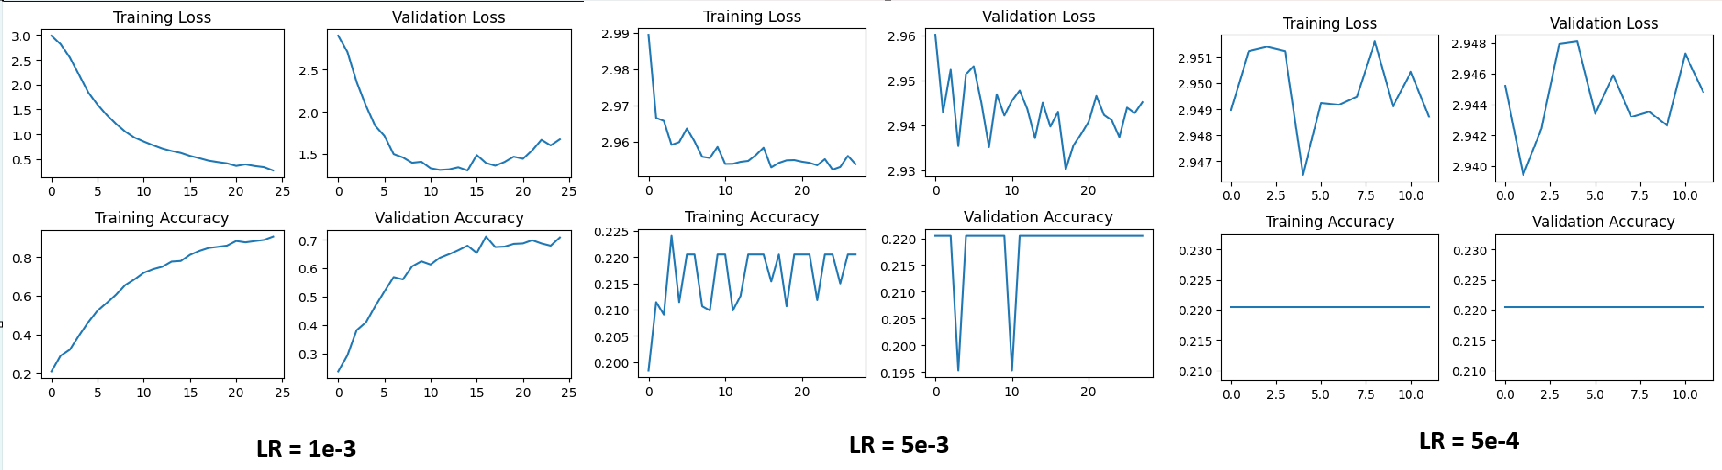



Epoch: 0 / 100
Mean Loss:  2.9851
Mean Accuracy:  0.2154
Mean Validation Accuracy:  0.2205
Val Loss:  2.9396
Epoch: 1 / 100
Mean Loss:  2.9159
Mean Accuracy:  0.2575
Mean Validation Accuracy:  0.2126
Val Loss:  2.8463
Epoch: 2 / 100
Mean Loss:  2.8109
Mean Accuracy:  0.2811
Mean Validation Accuracy:  0.2976
Val Loss:  2.7371
Epoch: 3 / 100
Mean Loss:  2.6967
Mean Accuracy:  0.3016
Mean Validation Accuracy:  0.2898
Val Loss:  2.6391
Epoch: 4 / 100
Mean Loss:  2.5447
Mean Accuracy:  0.3264
Mean Validation Accuracy:  0.3260
Val Loss:  2.5153
Epoch: 5 / 100
Mean Loss:  2.3661
Mean Accuracy:  0.3575
Mean Validation Accuracy:  0.4331
Val Loss:  2.2147
Epoch: 6 / 100
Mean Loss:  2.1056
Mean Accuracy:  0.4122
Mean Validation Accuracy:  0.4882
Val Loss:  2.0471
Epoch: 7 / 100
Mean Loss:  1.8029
Mean Accuracy:  0.4827
Mean Validation Accuracy:  0.4929
Val Loss:  1.7959
Epoch: 8 / 100
Mean Loss:  1.5723
Mean Accuracy:  0.5240
Mean Validation Accuracy:  0.5213
Val Loss:  1.6180
Epoch: 9 / 100
Mean

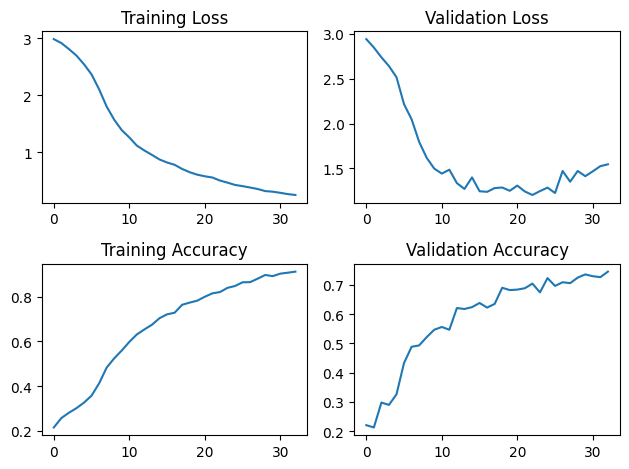

In [ ]:
Adam = optim.Adam(GRM.parameters(), lr = 1e-3)

Train(GRM, 
      Adam, 
      Data_Loader, 
      Val_Loader, 
      ClassWeights,
      "BestGRM.pth",
      100, 
      10)

In [81]:
GRM = GestureRecognitionModel()
GRM.load_state_dict(torch.load("BestGRM3.pth"))
GRM.eval()

GestureRecognitionModel(
  (CNN): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=3, stride=3, padding=1, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=3, stride=3, padding=1, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=3, stride=3, padding=1, dilation=1, ceil_mode=False)
  )
  (Classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6400, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=22, bias=True)
  )
)

### Evaluating the Model:

From the training process, we can see a ~70% accuracy to the validation data, however, there is a high cross entropy loss of ~1.6. As well as the evidence of the highly imbalanced nature of the dataset, we can quite confidently assume that the model is somewhat overfit to the majority classes, i.e TPose, Neutral, Cross. 

On a first glance, this might seem quite bad, and that we might not be able to use this for the A.M. However, it is important to remember that the way accuracy is determined in this case is by taking the class with the highest confidence prediction as being the one "Predicted" class, and comparing it to the "Correct" class. What is not being considered, is the confidence values for the other possible classes.

One example is this, consider an Image whose Correct label is TPose. In this image, however, the subject is in between movements and it looks somewhat like TLeftNeutral. Now let's say the model creates the prediction classes and says with highest confidence of 23% that the pose in the image is TLeftNeutral. By accuracy, this prediction is completely wrong. However, in reality, that model might have had TPose as a runner up class with confidence of 22%, which is something Accuracy misses.

To further investigate this phenomenon, I created the following code which will allow me to further investigate each Image, the model's prediction (the class with highest confidence level), and if it is wrong, what the confidence level for the correct label is. 

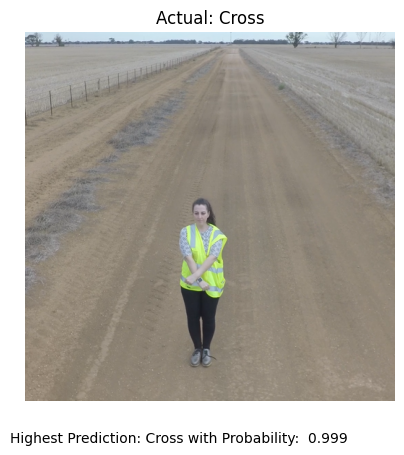

In [166]:
RandomNum = random.randint(0, len(Image_Val) - 1)
RandomImage, Label = Image_Val[RandomNum]

with torch.no_grad():
    ValLogits = GRM(RandomImage.unsqueeze(0))

ValLogits = torch.softmax(ValLogits, dim=1)
Label = int(Label.item())
Predicted = int(torch.argmax(ValLogits, dim=1).item())

plt.imshow(RandomImage.permute(1, 2, 0))
plt.axis("off")
plt.title(f"Actual: {GestureEncoder.inverse_transform([Label])[0]}")
plt.figtext(0.2, 0.025, f"Highest Prediction: {GestureEncoder.inverse_transform([Predicted])[0]} with Probability: {ValLogits[0][Predicted] : .3f}")

if Predicted != Label:
    plt.figtext(0.2, -0.025, f"Probability of Actual: {ValLogits[0][Label] : .3f}")

By looking through these images, I am able to have a further insight on my model's capabilities. As expected, the model is somewhat overfit to the majority classes, sometimes mislabelling a minority class as one of the majority classes. However, in many cases, the confidence of the correctly labelled class is not far behind the confidence level of the predicted class.

The model also can make mistakes by mislabelling certain similar gestures. ThumbsUp and ThumbsDown can sometimes be mixed up, Neutral and Front or Front and FrontMe are also some examples. Otherwise other mistakes can happen due to sheer lack of training data, such as having trouble determining FrontLeftNeutral and FrontLeftUp because of their low value counts in the training data. 

However, I still believe that this model is well fit enough for the A.M. Which will be explained in the next section.

## The Action Model

My plan for the A.M is to use the GRM in order to extract the confidence levels of each Image and then pass them through a dense layer which will act as the classifier. I don't want a simple Gesture from an Image, but the confidence levels for each Gesture. If in one frame, the subject makes a pose which the GRM is not entirely confident in, the Confidence levels of all the other frames should boost the model's likelihood of picking the correct classification. This is why I will not be using a Softmax and argmax in the GRM, and why I believe that the previous model was well enough fit for this task, because it yielded decent confidence levels for each image.

Below is what I have determined to be an apt architecture for the A.M. Important design decisions include: 
- The previous GRM which will be used to calculate Confidence levels for each frame before concatenating them.
- The classifier which contains one hidden layer with a ReLU activation function. The model seems to perform best with this configuration.

In [222]:
class ActionModel(nn.Module):
    def __init__(self, GRM):
        super(ActionModel, self).__init__()
        self.GRM = GRM

        self.Decider = nn.Sequential(
            nn.Linear(in_features = 110,
                      out_features = 64),
            nn.ReLU(),
            nn.Linear(in_features = 64,
                      out_features = 13)
        )
        
    def forward(self, input):
        self.GRM.eval()
        
        GestureOutputs = []
        
        with torch.no_grad():
            for i in range(5):
                GestureOutputs.append(self.GRM(input[: , i]))
        
        Combined = torch.concat(GestureOutputs, dim=1)
        Output = self.Decider(Combined)
        
        return Output

In [223]:
class ActionDataset(Dataset):
    def __init__(self, df):
        self.Data = df
        
    def __len__(self):
        return len(self.Data)

    def __getitem__(self, index):
        Row = self.Data.iloc[index]
        Images = []
        
        for i in range(5):
            Image = plt.imread(Row[f"Image{i+1}"])
            Image = torch.tensor(Image, dtype = torch.float32)
            Image = Image.permute(2, 0, 1)
            Images.append(Image)
        
        Images = torch.stack(Images)
        
        Action = torch.tensor(Row["Label"], dtype=torch.long)
        
        return Images, Action

In [224]:
Action_Train, Action_Val = train_test_split(RestData,
                                            test_size = 0.2,
                                            train_size = 0.8,
                                            random_state = 67,
                                            stratify = RestData["Label"])

ActionEncoder = LabelEncoder().fit(Action_Train["Label"])
Action_Train["Label"] = ActionEncoder.transform(Action_Train["Label"])
Action_Val["Label"] = ActionEncoder.transform(Action_Val["Label"])

In [225]:
Action_Train = ActionDataset(Action_Train)
Action_Val = ActionDataset(Action_Val)

In [226]:
BatchSize = 16

Data_Loader2 = DataLoader(Action_Train,
                          batch_size = BatchSize,
                          shuffle = True)

Val_Loader2 = DataLoader(Action_Val,
                         batch_size = 16,
                         shuffle = True)

Device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

GRM = GestureRecognitionModel()
GRM.load_state_dict(torch.load("BestGRM3.pth"))
AM = ActionModel(GRM)

In [227]:
ClassCounts = Action_Train.Data["Label"].value_counts().sort_index()

ClassWeights = len(Action_Train) / (
    len(ClassCounts) * ClassCounts
)

ClassWeights = torch.tensor(
    ClassWeights.to_numpy(),
    dtype=torch.float32
)

In [228]:
print(ClassWeights)

tensor([0.9313, 0.9658, 0.9658, 0.6686, 1.7385, 0.8149, 1.7385, 0.8692, 0.8692,
        1.3038, 0.9658, 0.8692, 1.3725])


### Training: 

I reused the same training process as before and decide to use 1e-3 for my learning rate. Because a bulk of the computation in A.M relies on GRM, I had no troubles with the training process. 1e-3 was fit for this task because it allowed the model to converge and generalize to unseen data. 5e-3 was too high and contained many spikes within the validation curve, resulting in a lower validation accuracy. 5e-4 is a contender, however, both contained a very smooth loss curve, resulting in good generalization. There is no substantial advantage of using the slower learning rate.

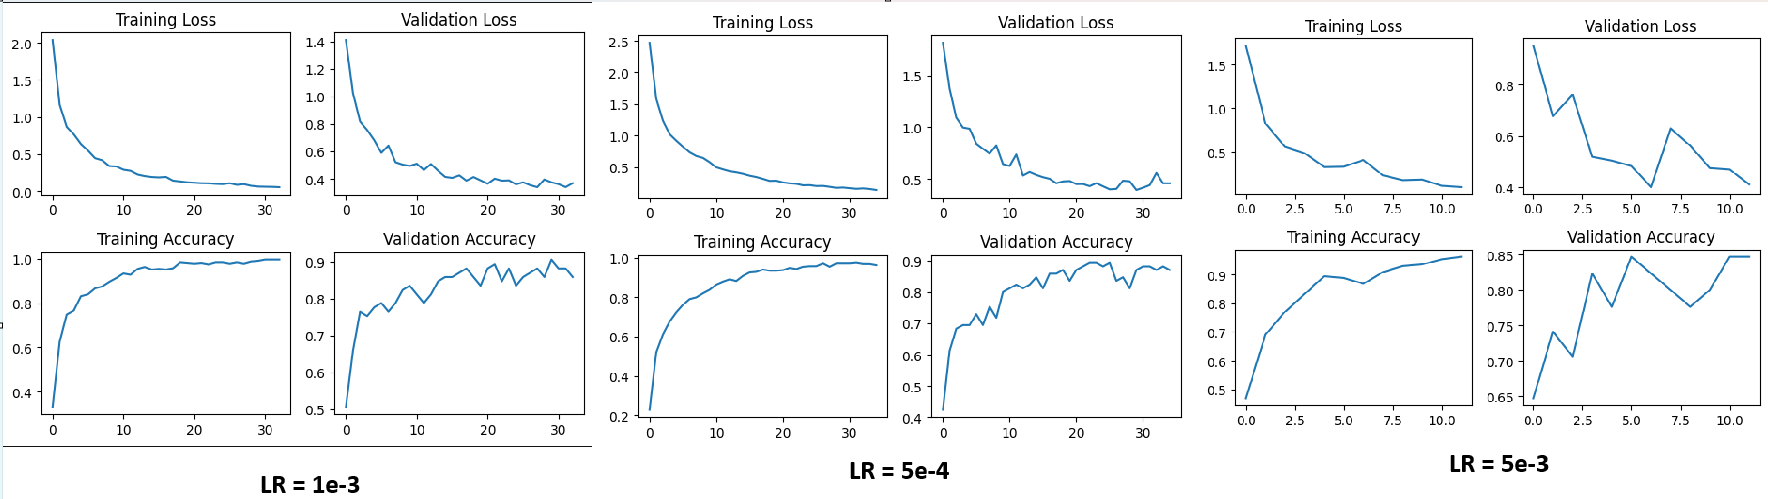


Epoch: 0 / 100
Mean Loss:  1.7181
Mean Accuracy:  0.4690
Mean Validation Accuracy:  0.6471
Val Loss:  0.9519
Epoch: 1 / 100
Mean Loss:  0.8251
Mean Accuracy:  0.6903
Mean Validation Accuracy:  0.7412
Val Loss:  0.6776
Epoch: 2 / 100
Mean Loss:  0.5585
Mean Accuracy:  0.7699
Mean Validation Accuracy:  0.7059
Val Loss:  0.7610
Epoch: 3 / 100
Mean Loss:  0.4854
Mean Accuracy:  0.8319
Mean Validation Accuracy:  0.8235
Val Loss:  0.5195
Epoch: 4 / 100
Mean Loss:  0.3283
Mean Accuracy:  0.8938
Mean Validation Accuracy:  0.7765
Val Loss:  0.5048
Epoch: 5 / 100
Mean Loss:  0.3324
Mean Accuracy:  0.8879
Mean Validation Accuracy:  0.8471
Val Loss:  0.4840
Epoch: 6 / 100
Mean Loss:  0.4077
Mean Accuracy:  0.8673
Mean Validation Accuracy:  0.8235
Val Loss:  0.4017
Epoch: 7 / 100
Mean Loss:  0.2302
Mean Accuracy:  0.9086
Mean Validation Accuracy:  0.8000
Val Loss:  0.6293
Epoch: 8 / 100
Mean Loss:  0.1754
Mean Accuracy:  0.9292
Mean Validation Accuracy:  0.7765
Val Loss:  0.5627
Epoch: 9 / 100
Mean

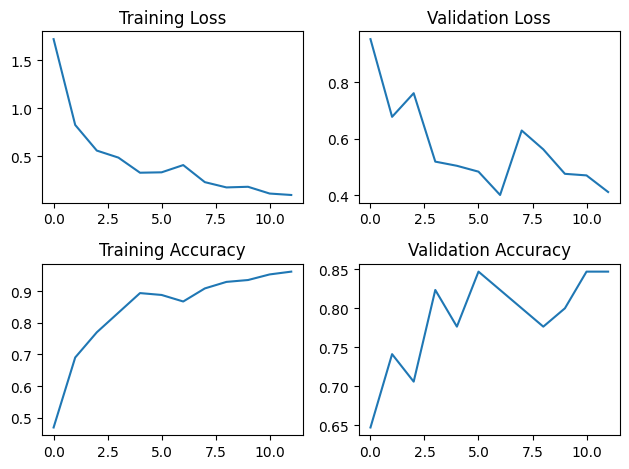

In [ ]:
Eve = optim.Adam(AM.parameters(), lr = 1e-3)

Train(AM,
      Eve,
      Data_Loader2,
      Val_Loader2,
      ClassWeights,
      "BestAM4.pth",
      100,
      5)

In [117]:
AM = ActionModel(GRM)
AM.load_state_dict(torch.load("BestAM3.pth"))
AM.eval()

ActionModel(
  (GRM): GestureRecognitionModel(
    (CNN): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=3, stride=3, padding=1, dilation=1, ceil_mode=False)
      (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=3, stride=3, padding=1, dilation=1, ceil_mode=False)
      (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): MaxPool2d(kernel_size=3, stride=3, padding=1, dilation=1, ceil_mode=False)
    )
    (Classifier): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=6400, out_features=128, bias=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=22, bias=True)
    )
  )
  (Decider): Sequential(
    (0): Linear(in_features=110, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=13, b

## Evaluating the Model: 

The final accuracy of the model I was left with yielded a ~88% accuracy on the validation data. One thing I noticed while training is the validation accuracy and validation loss of the last few epochs. I had noticed that some epochs yielded higher accuracies but lower loss scores. It suggests that because I chose to choose the best model based on validation loss instead of validation accuracy, that the model was able to avoid overfitting. Had the model been overfit, although model accuracy would be better, there might be a higher chance that minority classes could be misclassified for a majority class. 

Another thing I noticed from this model is how the performance of the GRM significantly effects the performance of the A.M. Because the performance of the GRM directly affects the reliability of each frame's confidence levels, having a GRM with slightly less reliable information significantly effects A.M. Testing with previous builds of GRM, I compared the difference in performance between a GRM with validation accuracy of ~65% to my final GRM which has a validation accuracy ~75%. In these tests, the first A.M had a mean accuracy of ~70% whereas the second had a mean accuracy of ~88%. With a higher GRM performance, I might have been able to get better A.M performance. 

To further investigate this model, I decided to reimplement the same investigative code which allows me to view a sample Action string and the corresponding classifier's label.

torch.Size([5, 3, 512, 512])


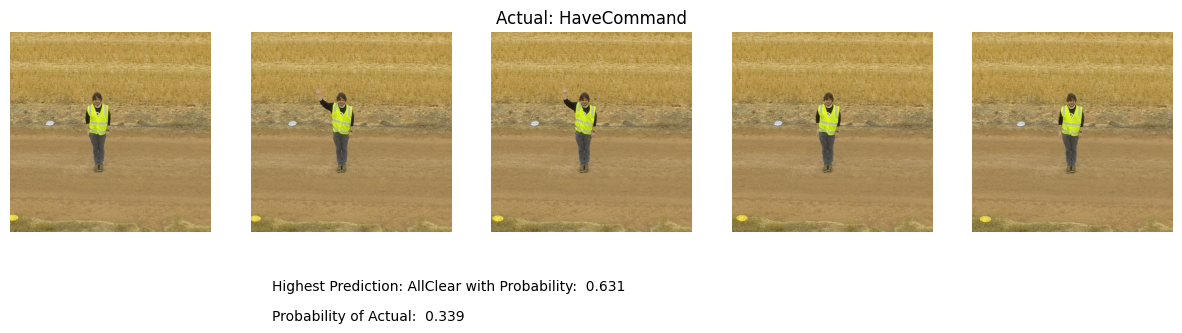

In [213]:
RandomNum = random.randint(0, len(Action_Val) - 1)
RandomImages, Label = Action_Val[RandomNum]

with torch.no_grad():
    ValLogits = AM(RandomImages.unsqueeze(0))
    
ValLogits = torch.softmax(ValLogits, dim=1)
Label = int(Label.item())
Predicted = int(torch.argmax(ValLogits, dim=1).item())

fig, ax = plt.subplots(1, 5, figsize=(15, 4))

print(RandomImages.shape)

for i in range(5):
    ax[i].imshow(RandomImages[i].permute(1, 2, 0))
    ax[i].axis("off")
    
ax[2].set_title(f"Actual: {ActionEncoder.inverse_transform([Label])[0]}")
fig.text(0.3, 0.1, f"Highest Prediction: {ActionEncoder.inverse_transform([Predicted])[0]} with Probability: {ValLogits[0][Predicted] : .3f}")

if Predicted != Label:
    fig.text(0.3, 0.025, f"Probability of Actual: {ValLogits[0][Label] : .3f}")

What I noticed is that within Actions that are correctly classified, they all have a very high confidence level attached to them. Whereas in GRM, the highest confidence level always fluctuates from Image to Image even when they are correctly classified, in here correctly classified Images will almost always have a Confidence Probability > 0.9. However, I also found that among mislabelled classes, the highest confidence level Action, as well as the Correct Action will have a significantly lower confidence level, implying that for these Action strings the model is incredibly confused and cannot give a clear classification.

Among these incorrectly classified Actions, 

## Executive Summary:

- I don't believe the current model is ready to be shipped as is to safety critical deployment.
- Current training dataset used for the model has the following constraints including: 
- 1. Limited number of samples, the resulting models can and will perform better with more training data.
- 2. Limited number of samples for each 

### AI Usage:

AI-Model: GitHub Co-Pilot Auto

Summary: Create a helper function to display a row of Images associated with a command (which is passed as a parameter). 

Returned: display_command_images() Function.

Prompt: "Create a function that will display the five images associated with one instance from one of the 13 commands which will be passed in as a parameter."

Text Output:

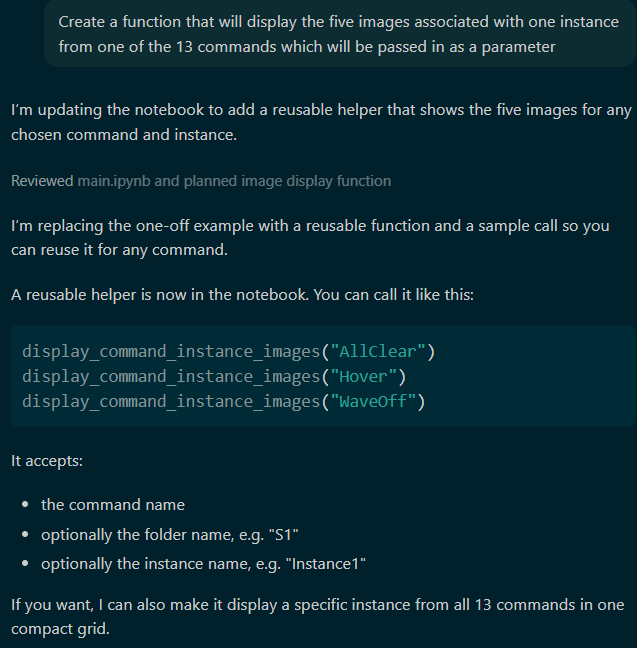 

Code Output: 

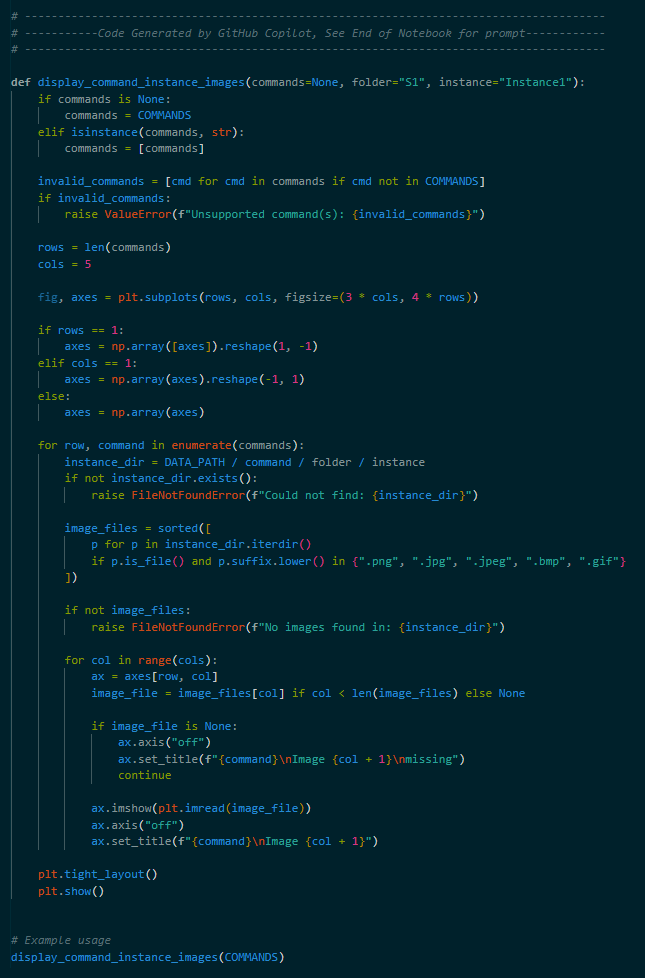